---
title: Dataset Preprocessing
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

After creating the dataset of AR events with scalar characteristics and impacts of each storm, we now preprocess and clean the catalog. 

In [12]:
import xarray as xr
import pandas as pd
import numpy as np
from artools.display_utils import display_catalog
from artools.format_utils import relabel_storms

In [2]:
dataset = pd.read_hdf('../outputs/data_products/full_AR_df.h5')

First, notice that some storms have a value of $-1$ for the variable indicating the maximum sea level pressure gradient underneath the AR footprint, over the ocean at the time of first landfall (`max_ocean_SLP_gradient`). This occurs when an AR, at the time of first landfall, has no portion of its footprint over the Southern Ocean.

Further, notice that some storms have a value of $-1$ for their value of the maximum landfalling poleward 850 hPa wind (`max_landfalling_v850hPa`), taken over the southern ocean at the time of first landfall. Similarly this value is taken on if, at the time of first landfall, there is no portion of the AR footprint over the Southern Ocean.

We wish to exclude both of these kinds of storms from the analysis.

In [3]:
no_ocean_component_SLP = dataset[dataset.max_ocean_SLP_gradient.isna()]
no_ocean_component_v850 = dataset[dataset.max_landfalling_v850hPa.isna()]

Just to be sure, we check that all of the storms for which the SLP gradient is $-1$ are also storms whose 850 hPa wind is $-1$, and vice versa.

In [4]:
all(no_ocean_component_SLP.index == no_ocean_component_v850.index)

True

There are 83 such storms, out of 3165 identified in total. Filtering them out should not significantly skew results.

In [5]:
(no_ocean_component_SLP.shape[0], dataset.shape[0])

(83, 3165)

In [6]:
dataset = dataset[dataset.max_ocean_SLP_gradient > -1]

Let's further check if there are any missing values in any column.

In [7]:
dataset.isna().any()

data_array                     False
is_landfalling                 False
max_area                       False
mean_landfalling_area          False
cumulative_landfalling_area    False
duration                       False
start_date                     False
end_date                       False
max_south_extent               False
region                         False
max_T2M_anomaly_ais            False
max_IWV_ais                    False
max_IWV_anomaly_ais            False
max_ocean_SLP_gradient         False
cumulative_rainfall_ais        False
cumulative_snowfall_ais        False
avg_landfalling_minomega       False
max_landfalling_v850hPa        False
max_vIVT_ais                   False
dtype: bool

Now, let's get summary statistics of each column as well.

In [8]:
df_no_dataarrays = dataset.drop(columns=['data_array'])

In [9]:
df_no_dataarrays.describe()

,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2M_anomaly_ais,max_IWV_ais,max_IWV_anomaly_ais,max_ocean_SLP_gradient,cumulative_rainfall_ais,cumulative_snowfall_ais,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais
count,3.082000e+03,3.082000e+03,3.082000e+03,3082.000000,3082,3082,3082.000000,3082.000000,3082.000000,3082.000000,3082.000000,3.082000e+03,3.082000e+03,3082.000000,3082.000000,3082.000000
mean,1.646144e+06,2.872571e+05,4.158155e+05,31.844581,2002-04-27 08:37:06.346528256,2002-04-28 15:09:31.187540608,-77.382219,14.619806,10.763843,6.606320,5.770712,2.477481e+10,5.439247e+12,-0.598406,29.355413,204.567727
min,7.765000e+03,5.400000e+01,1.040000e+02,3.000000,1980-01-02 00:00:00,1980-01-03 18:00:00,-85.000000,-3.375671,1.609859,0.447205,0.929378,0.000000e+00,8.903395e+07,-2.733001,-2.182174,8.646878
25%,1.151325e+06,3.490350e+04,2.637150e+04,12.000000,1991-07-05 18:00:00,1991-07-08 07:30:00,-84.000000,8.408958,7.950456,4.469370,4.472249,0.000000e+00,9.760093e+11,-0.749641,25.184466,127.645023
50%,1.557740e+06,1.611290e+05,1.205080e+05,27.000000,2002-11-04 01:30:00,2002-11-05 04:30:00,-77.500000,14.004471,10.463204,6.311406,5.562944,0.000000e+00,3.145381e+12,-0.562215,29.263287,188.883667
75%,2.065956e+06,4.309050e+05,4.893788e+05,45.000000,2013-04-03 12:45:00,2013-04-05 18:00:00,-72.500000,20.434593,13.011727,8.254913,6.952475,1.598356e+09,7.633871e+12,-0.400792,33.392294,265.008476
max,5.842192e+06,2.232080e+06,7.336100e+06,162.000000,2022-12-31 12:00:00,2022-12-31 21:00:00,-63.500000,40.972366,29.251392,20.543856,13.501285,3.441223e+12,7.125174e+13,-0.028048,51.032520,748.183411
std,7.301755e+05,3.387756e+05,6.956863e+05,23.496287,NaN,NaN,6.049569,7.995746,3.902051,2.857599,1.785317,1.248402e+11,6.493936e+12,0.286673,6.219412,104.538133


Now, let's get the amount of precipitation in gigatons.

In [10]:
dataset['cumulative_rainfall_ais'] = dataset['cumulative_rainfall_ais']/(10**13)
dataset['cumulative_snowfall_ais'] = dataset['cumulative_snowfall_ais']/(10**13)

Let's also adopt a cleaner naming convention for storms. The convention will be `YYYY-x` where `YYYY` is the year of formation and `x` is the xth storm of that year.

In [14]:
dataset = relabel_storms(dataset, 'start_date')

,data_array,is_landfalling,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,region,max_T2M_anomaly_ais,max_IWV_ais,max_IWV_anomaly_ais,max_ocean_SLP_gradient,cumulative_rainfall_ais,cumulative_snowfall_ais,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais
Label,,,,,,,,,,,,,,,,,,,
1980_1,,True,1906980,14234,26690,45,1980-01-02 00:00:00,1980-01-03 18:00:00,-74.500000,West,4.733398,19.393877,12.256676,4.899358,0.001312,0.055527,-0.327016,26.413338,278.429169
1980_2,,True,1755659,190118,332707,42,1980-01-06 18:00:00,1980-01-08 12:00:00,-74.000000,East 2,9.100540,15.271224,9.018206,5.984890,0.014628,0.693989,-0.377550,27.332188,236.822678
1980_3,,True,735749,210763,52690,6,1980-01-11 12:00:00,1980-01-11 15:00:00,-85.000000,West,4.731720,9.877011,3.414210,2.867155,0.001660,0.120147,-0.375955,23.885662,178.436508
1980_4,,True,1466805,119788,149735,30,1980-01-12 03:00:00,1980-01-13 09:00:00,-85.000000,East 2,8.239502,12.215693,6.718226,4.138897,0.002630,0.294429,-0.169118,27.479479,203.303299
1980_5,,True,2564243,1069995,1604992,36,1980-01-14 12:00:00,1980-01-16 09:00:00,-85.000000,East 1,12.359955,16.230389,10.178875,3.984146,0.045758,1.596362,-0.462177,24.461037,358.498505

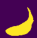
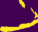
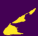

In [17]:
display_catalog(dataset, 5)

Now, let's save this cleaned dataset to a separate hdf5 file.

In [18]:
dataset.to_hdf('../outputs/data_products/full_dataset_clean.h5', key='df')

/tmp/ipykernel_212443/2659646790.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block5_values] [items->Index(['data_array'], dtype='str')]

  dataset.to_hdf('../outputs/data_products/full_dataset_clean.h5', key='df')


Let's also save the dataset with a subset of columns, removing those columns which cannot be properly saved to csv. This will facilitate loading of the data into R, for example, when fitting the `gbex` models.

In [19]:
loadable_R_cleaned = dataset.drop(columns=['data_array', 'is_landfalling', 'start_date', 'end_date'])
loadable_R_cleaned.to_csv('../outputs/data_products/full_dataset_clean.csv')

Finally, let's perform our train/test split, which we will use to train and evaluate our models.

In [21]:
# train/test split
np.random.seed(12345)
n = loadable_R_cleaned.shape[0]
inds = np.arange(0, n)
frac_test = 0.2
test_inds = np.random.choice(inds, size=int(n*frac_test), replace=False)
train_inds = np.setdiff1d(inds, test_inds, assume_unique=True)

train_data = loadable_R_cleaned.iloc[train_inds]
test_data = loadable_R_cleaned.iloc[test_inds]

train_data.to_csv('../outputs/data_products/train.csv')
test_data.to_csv('../outputs/data_products/test.csv')